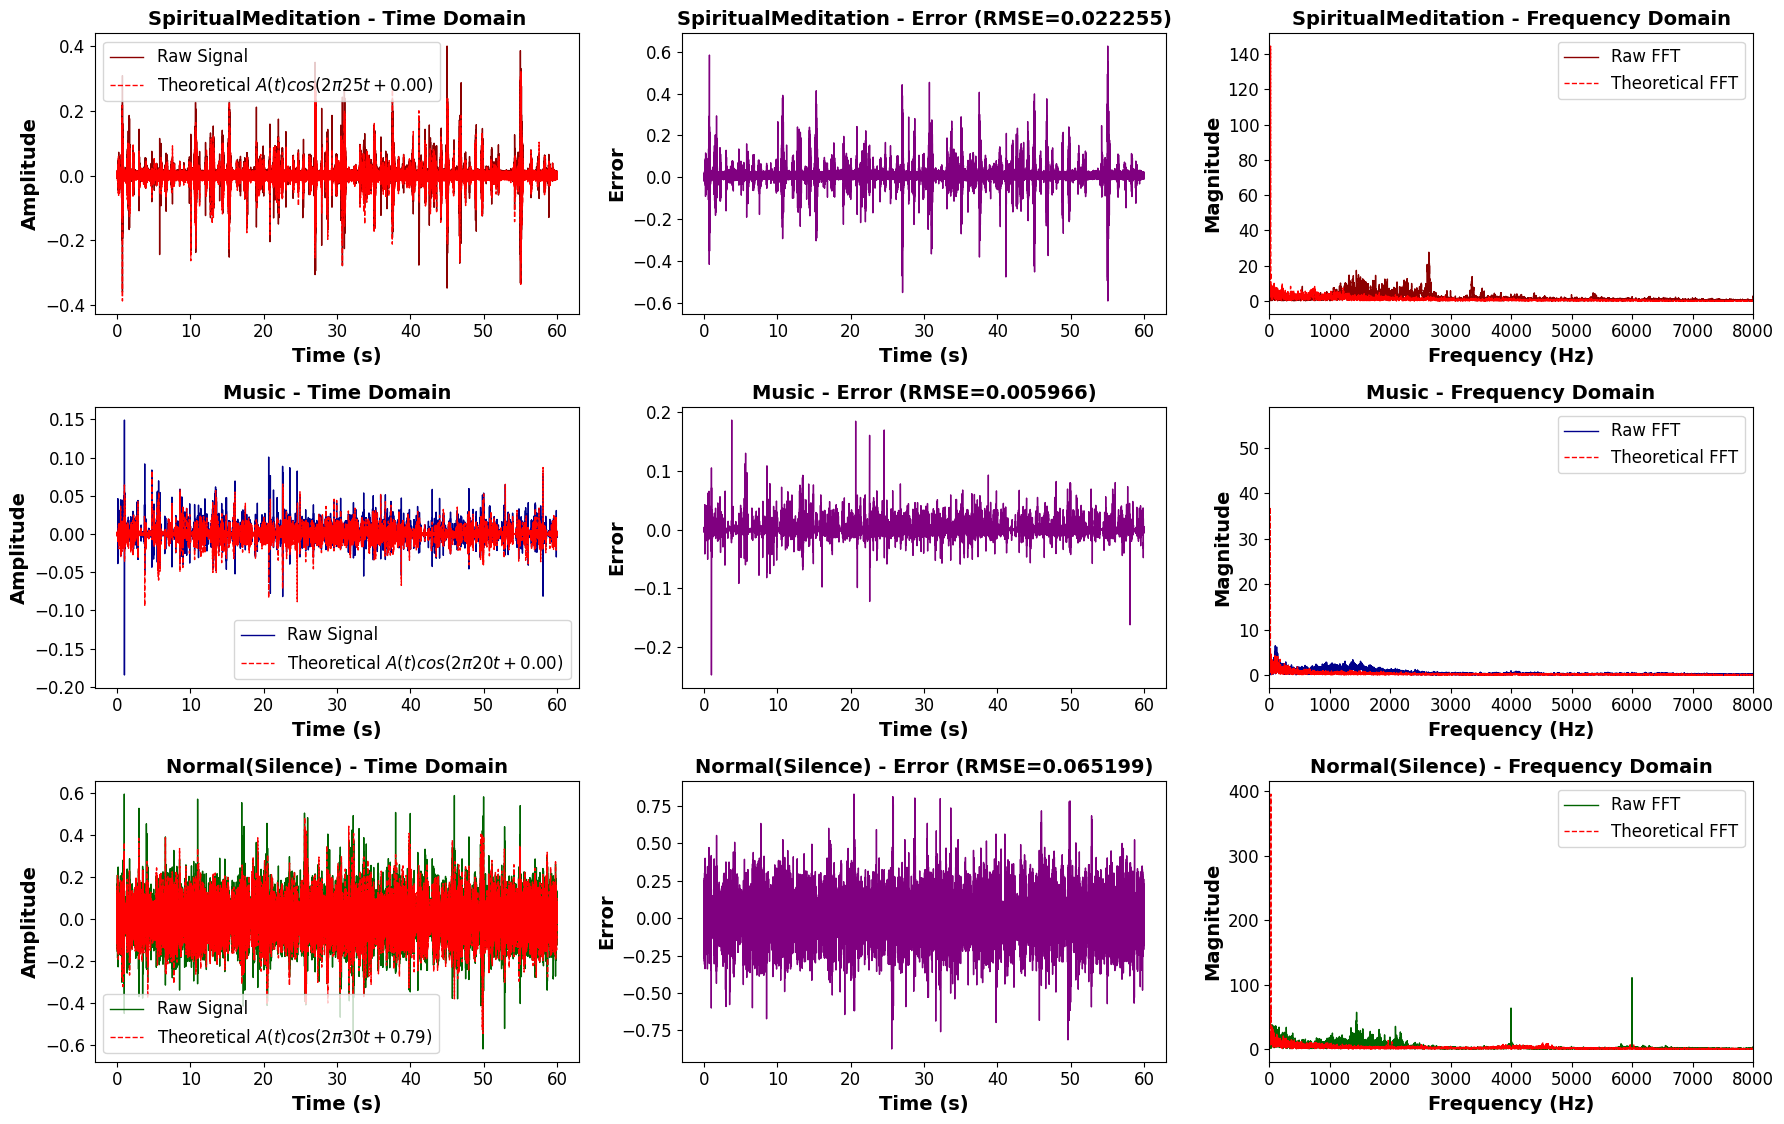


📊 Summary Statistics for Each Class:
              Class     RMSE  Mean Envelope  Std Envelope      Energy
SpiritualMeditation 0.022255       0.012768      0.018084  246.874207
              Music 0.005966       0.003912      0.004373   17.694057
    Normal(Silence) 0.065199       0.052644      0.039605 2096.641113


In [1]:
import os
import random
import glob
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import hilbert
from pathlib import Path
import pandas as pd

# ----------------------------
# Global Settings
# ----------------------------
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

# Define dark colors for each class.
class_colors = {
    "SpiritualMeditation": "#8B0000",      # Dark Red
    "Music": "#00008B",                    # Dark Blue
    "Normal(Silence)": "#006400"           # Dark Green
}

# ----------------------------
# 1. Raw Audio Dataset
# ----------------------------
class RawAudioDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, sample_rate=16000):
        self.sample_rate = sample_rate
        self.classes = ["SpiritualMeditation", "Music", "Normal(Silence)"]
        self.file_paths = []
        self.labels = []
        for cls in self.classes:
            # Updated: include "Generated-data" folder inside each class folder
            folder = Path(root_dir) / cls / "Generated-data"
            wav_files = glob.glob(str(folder / '*.wav'))
            if wav_files:
                self.file_paths.extend(wav_files)
                self.labels.extend([cls] * len(wav_files))
            else:
                print(f"⚠️ Warning: No .wav files found for '{cls}' in {folder}")
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform, sr = torchaudio.load(file_path)
        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)
        if waveform.dim() == 2:  # Stereo → Mono
            waveform = waveform[0].unsqueeze(0)
        label = self.labels[idx]
        return waveform, label

# ----------------------------
# 2. Signal Processing Functions
# ----------------------------
def compute_amplitude_envelope(waveform):
    """Compute amplitude envelope using Hilbert transform."""
    data = waveform.numpy().flatten()
    analytic_signal = hilbert(data)
    envelope = np.abs(analytic_signal)
    return envelope

def theoretical_signal(envelope, t, fc, phi):
    """Construct theoretical cosine-modulated signal."""
    return envelope * np.cos(2 * np.pi * fc * t + phi)

def compute_rmse(x, y):
    return np.sqrt(np.mean((x - y)**2))

def compute_fft(waveform, sample_rate=16000, fft_size=16384):
    """Compute single-sided FFT magnitude spectrum."""
    data = waveform.numpy().flatten()
    if len(data) < fft_size:
        data_fixed = np.pad(data, (0, fft_size - len(data)), mode='constant')
    else:
        data_fixed = data[:fft_size]
    fft_vals = np.fft.fft(data_fixed)
    fft_freq = np.fft.fftfreq(len(fft_vals), 1.0 / sample_rate)
    pos_mask = fft_freq >= 0
    return fft_freq[pos_mask], np.abs(fft_vals)[pos_mask]

# ----------------------------
# 3. Statistical Analysis
# ----------------------------
def compute_time_stats(waveform):
    """Compute time-domain statistics."""
    data = waveform.numpy().flatten()
    return {
        "RMS": np.sqrt(np.mean(data**2)),
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "Energy": np.sum(data**2)
    }

# ----------------------------
# 4. Main Processing and Plotting Function
# ----------------------------
def process_and_plot(sample_rate=16000, fft_size=16384):
    # ✅ Updated root directory to SMSAT-generated dataset
    root_dir = '/kaggle/input/qmsat-dataset/SMSAT-generated-data/SMSAT-generated-data'
    dataset = RawAudioDataset(root_dir, sample_rate=sample_rate)
    
    params = {
        "SpiritualMeditation": {"fc": 25, "phi": 0},
        "Music": {"fc": 20, "phi": 0},
        "Normal(Silence)": {"fc": 30, "phi": np.pi / 4}
    }
    
    summary_list = []
    fig, axs = plt.subplots(3, 3, figsize=(18, 12))
    
    for i, cls in enumerate(dataset.classes):
        indices = [j for j, lab in enumerate(dataset.labels) if lab == cls]
        if not indices:
            print(f"Skipping class {cls}: no samples found.")
            for k in range(3):
                axs[i, k].set_visible(False)
            continue
        
        sample_idx = random.choice(indices)
        waveform, _ = dataset[sample_idx]
        data = waveform.numpy().flatten()
        N = len(data)
        t = np.linspace(0, N / sample_rate, N)
        
        envelope = compute_amplitude_envelope(waveform)
        fc, phi = params[cls]["fc"], params[cls]["phi"]
        theo = theoretical_signal(envelope, t, fc, phi)
        rmse = compute_rmse(data, theo)
        
        stats = {
            "Class": cls,
            "RMSE": rmse,
            "Mean Envelope": np.mean(envelope),
            "Std Envelope": np.std(envelope),
            "Energy": np.sum(data**2)
        }
        summary_list.append(stats)
        
        freq_raw, fft_raw = compute_fft(waveform, sample_rate, fft_size)
        freq_theo, fft_theo = compute_fft(torch.tensor(theo), sample_rate, fft_size)
        
        # --- Time Domain ---
        axs[i, 0].plot(t, data, color=class_colors[cls], label="Raw Signal", linewidth=1)
        axs[i, 0].plot(t, theo, color="red", linestyle="--",
                       label=f"Theoretical $A(t)cos(2π{fc}t+{phi:.2f})$", linewidth=1)
        axs[i, 0].set_title(f"{cls} - Time Domain", fontsize=14, fontweight="bold")
        axs[i, 0].set_xlabel("Time (s)", fontsize=14, fontweight="bold")
        axs[i, 0].set_ylabel("Amplitude", fontsize=14, fontweight="bold")
        axs[i, 0].legend(fontsize=12)
        
        # --- Error Signal ---
        error = data - theo
        axs[i, 1].plot(t, error, color="purple", linewidth=1)
        axs[i, 1].set_title(f"{cls} - Error (RMSE={rmse:.6f})", fontsize=14, fontweight="bold")
        axs[i, 1].set_xlabel("Time (s)", fontsize=14, fontweight="bold")
        axs[i, 1].set_ylabel("Error", fontsize=14, fontweight="bold")
        
        # --- Frequency Domain ---
        axs[i, 2].plot(freq_raw, fft_raw, color=class_colors[cls], linewidth=1, label="Raw FFT")
        axs[i, 2].plot(freq_theo, fft_theo, color="red", linestyle="--", label="Theoretical FFT", linewidth=1)
        axs[i, 2].set_xlim([0, sample_rate / 2])
        axs[i, 2].set_title(f"{cls} - Frequency Domain", fontsize=14, fontweight="bold")
        axs[i, 2].set_xlabel("Frequency (Hz)", fontsize=14, fontweight="bold")
        axs[i, 2].set_ylabel("Magnitude", fontsize=14, fontweight="bold")
        axs[i, 2].legend(fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("/kaggle/working/signal_comparison_all_classes.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Summary Table
    df_summary = pd.DataFrame(summary_list)
    print("\n📊 Summary Statistics for Each Class:")
    print(df_summary.to_string(index=False))

# ----------------------------
# 5. Main Execution
# ----------------------------
if __name__ == "__main__":
    process_and_plot()
